In [1]:
HYPERPARAM_ITERS = 50  # Number of iterations for hyperparameter tuning;
EXPORT = True  # Whether to export the trained models; set to True to save the models to disk.

# Data Preprocessing

While we did a lot of data cleaning and preprocessing in other notebooks (see notebooks in [data directory](./data)), we will load the data here and do some additional preprocessing to prepare it for model training. This includes combining flight and weather data, adding some historical and derived columns, as well as encoding categorical variables and splitting the data into training and testing sets.

In [2]:
import polars as pl

# Load the data
df = pl.read_parquet("data/flights/Full_Flight_Data.parquet")
df = df.sort("FL_DATE")
df.shape, df.head(), df.tail()

((480802, 60),
 shape: (5, 60)
 ┌─────────────┬─────────────┬────────────┬────────────┬───┬───────┬────────────┬────────────┬──────┐
 │ FL_DATE     ┆ MKT_UNIQUE_ ┆ MKT_CARRIE ┆ OP_UNIQUE_ ┆ … ┆ SPEED ┆ TC-DATA-SH ┆ TC-DATA-HO ┆      │
 │ ---         ┆ CARRIER     ┆ R_FL_NUM   ┆ CARRIER    ┆   ┆ ---   ┆ EET        ┆ LDER       ┆ ---  │
 │ datetime[μs ┆ ---         ┆ ---        ┆ ---        ┆   ┆ str   ┆ ---        ┆ ---        ┆ str  │
 │ ]           ┆ str         ┆ i64        ┆ str        ┆   ┆       ┆ str        ┆ str        ┆      │
 ╞═════════════╪═════════════╪════════════╪════════════╪═══╪═══════╪════════════╪════════════╪══════╡
 │ 2024-01-01  ┆ AA          ┆ 1064       ┆ AA         ┆ … ┆ 0000  ┆ A28NM      ┆ AIRBUS SAS ┆ null │
 │ 00:00:00    ┆             ┆            ┆            ┆   ┆       ┆            ┆ …          ┆      │
 │ 2024-01-01  ┆ AA          ┆ 1153       ┆ AA         ┆ … ┆ 0000  ┆            ┆ …          ┆ null │
 │ 00:00:00    ┆             ┆            ┆        

In [3]:
# Drop non-DCA originating flights
df = df.filter(pl.col("ORIGIN_AIRPORT_ID") == 11278)
df.shape, df.columns

((240391, 60),
 ['FL_DATE',
  'MKT_UNIQUE_CARRIER',
  'MKT_CARRIER_FL_NUM',
  'OP_UNIQUE_CARRIER',
  'OP_CARRIER_AIRLINE_ID',
  'TAIL_NUM',
  'OP_CARRIER_FL_NUM',
  'ORIGIN_AIRPORT_ID',
  'ORIGIN_CITY_MARKET_ID',
  'ORIGIN',
  'DEST_AIRPORT_ID',
  'CRS_DEP_TIME',
  'DEP_TIME',
  'DEP_DELAY',
  'DEP_DELAY_GROUP',
  'TAXI_OUT',
  'WHEELS_OFF',
  'WHEELS_ON',
  'TAXI_IN',
  'CRS_ARR_TIME',
  'ARR_TIME',
  'ARR_DELAY',
  'CANCELLED',
  'CANCELLATION_CODE',
  'DIVERTED',
  'CRS_ELAPSED_TIME',
  'ACTUAL_ELAPSED_TIME',
  'AIR_TIME',
  'FLIGHTS',
  'DISTANCE',
  'CARRIER_DELAY',
  'WEATHER_DELAY',
  'NAS_DELAY',
  'SECURITY_DELAY',
  'LATE_AIRCRAFT_DELAY',
  'FIRST_DEP_TIME',
  'DIV_AIRPORT_LANDINGS',
  'DIV_REACHED_DEST',
  'DIV_ACTUAL_ELAPSED_TIME',
  'N-NUMBER',
  'SERIAL NUMBER',
  'MFR MDL CODE',
  'ENG MFR MDL',
  'YEAR MFR',
  'N_NUMBER_CLEAN',
  'MFR_CODE_CLEAN',
  'CODE',
  'MFR',
  'MODEL',
  'TYPE-ACFT',
  'TYPE-ENG',
  'AC-CAT',
  'BUILD-CERT-IND',
  'NO-ENG',
  'NO-SEATS',
  'AC-W

In [4]:
# Bring in weather data
weather_df = pl.read_parquet("data/weather/isd_weather_data.parquet").sort("timestamp")

# Calculate the actual scheduled departure timestamp from the flight date and scheduled departure time. This keeps the weather alignment consistent with weather info that would have been available at the time of the scheduled departure
df = df.with_columns(
    (
        pl.col("FL_DATE")
        + pl.duration(
            hours=(pl.col("CRS_DEP_TIME") // 100).cast(pl.Int64),
            minutes=(pl.col("CRS_DEP_TIME") % 100).cast(pl.Int64),
        )
    ).alias("scheduled_departure_ts")
).sort("scheduled_departure_ts")

# Merge in most recent weather data that would have been known by scheduled departure
df = df.join_asof(
    weather_df,
    left_on="scheduled_departure_ts",
    right_on="timestamp",
    strategy="backward",
    tolerance="3h",
).drop("timestamp")
df.shape, df.tail(), df.get_column("scheduled_departure_ts")

((240391, 73),
 shape: (5, 73)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ FL_DATE   ┆ MKT_UNIQU ┆ MKT_CARRI ┆ OP_UNIQUE ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_ │
 │ ---       ┆ E_CARRIER ┆ ER_FL_NUM ┆ _CARRIER  ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ height_m │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ μs]       ┆ str       ┆ i64       ┆ str       ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 2025-08-2 ┆ AA        ┆ 4346      ┆ YX        ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
 │ 7         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 00:00:00  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 2025-08-2 ┆ AA        ┆ 4643      ┆ YX        ┆ 

In [5]:
import holidays

# Time-of-day feature column names
TOD_MONTH = "month"
TOD_DOW = "day_of_week"
TOD_DOM = "day_of_month"
TOD_WEEKEND = "is_weekend"
TOD_HOLIDAY = "is_holiday"

# All derived from scheduled_departure_ts (FL_DATE + CRS_DEP_TIME);
df = df.with_columns(
    [
        pl.col("scheduled_departure_ts").dt.weekday().alias(TOD_DOW),  # 0=Mon, 6=Sun
        pl.col("scheduled_departure_ts").dt.month().cast(pl.Int8).alias(TOD_MONTH),
        pl.col("scheduled_departure_ts").dt.day().cast(pl.Int8).alias(TOD_DOM),
        (pl.col("scheduled_departure_ts").dt.weekday() >= 5)
        .cast(pl.Int8)
        .alias(TOD_WEEKEND),
        (
            pl.col("scheduled_departure_ts")
            .dt.date()
            .map_elements(lambda x: x in holidays.US())  # ty:ignore[unresolved-attribute]
            .cast(pl.Int8)
        ).alias(TOD_HOLIDAY),
    ]
)
df.select([TOD_DOW, TOD_MONTH, TOD_WEEKEND, TOD_HOLIDAY]).head()

day_of_week,month,is_weekend,is_holiday
i8,i8,i8,i8
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1


In [6]:
df = df.with_columns(
    pl.col(
        "MODEL"
    ).str.strip_chars()  # Remove leading/trailing whitespace from MODEL column (e.g., "737-800 " -> "737-800"
)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,MFR MDL CODE,ENG MFR MDL,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday
datetime[μs],str,i64,str,i64,str,i64,i64,i64,str,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,…,str,str,i32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,datetime[μs],f64,f64,f64,f64,f64,str,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,"""13844CB""","""13804""",2012,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,"""13844FZ""","""13134""",2018,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,"""3930326""","""""",1998,"""651AW""","""3930326""","""3930326""","""AIRBUS INDUSTRIE ""","""A320-232""","""5""","""5 ""","""1""","""0""","""02""","""200""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,"""3940010""","""13802""",2002,"""375NC""","""3940010""","""3940010""","""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,"""13844BZ""","""13802""",2000,"""37255""","""13844BZ""","""13844BZ""","""BOEING ""","""737-824""","""5""","""5 ""","""1""","""0""","""02""","""149""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1


In [7]:
df = df.with_columns(
    pl.col(pl.Utf8).cast(pl.Categorical),
    pl.col("scheduled_departure_ts").dt.epoch(
        time_unit="s"
    ),  # Convert datetime to epoch seconds
)

# Drop cancelled flights, and then drop any rows with null values
df = df.filter(pl.col("CANCELLED") == 0)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,MFR MDL CODE,ENG MFR MDL,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday
datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,i64,…,cat,cat,i32,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,"""13844CB""","""13804""",2012,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,"""13844FZ""","""13134""",2018,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,"""3930326""","""""",1998,"""651AW""","""3930326""","""3930326""","""AIRBUS INDUSTRIE ""","""A320-232""","""5""","""5 ""","""1""","""0""","""02""","""200""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,"""3940010""","""13802""",2002,"""375NC""","""3940010""","""3940010""","""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,"""13844BZ""","""13802""",2000,"""37255""","""13844BZ""","""13844BZ""","""BOEING ""","""737-824""","""5""","""5 ""","""1""","""0""","""02""","""149""","""CLASS 3""","""0000""",""" """,""" …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1


## Prepare the data for model training

In [8]:
# Extract features and target variable for both classification and regression models
cols = [
    # Flight info
    # "scheduled_departure_ts",
    "MKT_UNIQUE_CARRIER",
    # "MKT_CARRIER_FL_NUM",
    "DEST_AIRPORT_ID",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    # "DEP_TIME",
    # "DEP_DELAY",
    "DISTANCE",
    # "MODEL",
    # "avg_rte_delay",
    # "deps_last_1h",
    # "deps_last_3h",
    # "deps_last_6h",
    # "deps_last_12h",
    # "deps_last_24h",
    # "carrier_avg_delay_week",
    # "carrier_avg_delay_month",
    # "carrier_cancel_rate_month",
    # "carrier_cancel_rate_week",
    # "airport_avg_delay_hour",
    # "airport_cancel_rate_hour",
    # "airport_avg_delay_day",
    # "airport_cancel_rate_day",
    # "airport_avg_delay_week",
    # "airport_cancel_rate_week",
    # "airport_avg_delay_month",
    # "airport_cancel_rate_month",
    # Distance features
    # "dist_log",
    # "dist_bucket",
    # "dist_x_weather_severity",
    # Time of day features
    # "tod_hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_holiday",
    # "tod_departure_bucket",
    # "tod_hour_sin",
    # "tod_hour_cos",
    # Weather info
    "temp",
    "dewtemp",
    "pressure",
    "winddirection",
    "windspeed",
    # "skycoverage",
    # "precipitation-1h",
    # "precipitation-6h",
    # "precip-1h_trace",
    # "precip-6h_trace",
    # "visibility_m",
    # "ceiling_height_m",
]
df = df.select(cols + ["DEP_DELAY"])
df = df.drop_nulls()
x = df.select(cols)
# y is going to be whether the flight was delayed by more than 15 minutes or not
y = df.select("DEP_DELAY") > 15
x.head()

MKT_UNIQUE_CARRIER,DEST_AIRPORT_ID,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,day_of_week,day_of_month,month,is_weekend,is_holiday,temp,dewtemp,pressure,winddirection,windspeed
cat,i64,i64,i64,f64,f64,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64
"""AA""",11057,500,638,98.0,331.0,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0
"""AA""",13303,500,749,169.0,919.0,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0
"""AA""",15304,600,831,151.0,814.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5
"""DL""",10397,600,804,124.0,547.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5
"""UA""",13930,600,717,137.0,612.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5


## Encode categorical features

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [col for col in x.columns if x[col].dtype == pl.Categorical]

# create column transformer -- https://stackoverflow.com/a/77965041
transformer = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="polars")

# Fit and transform the data
transformer.fit(df.select(cols))
x = transformer.transform(x)
x.head()

MKT_UNIQUE_CARRIER,DEST_AIRPORT_ID,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,day_of_week,day_of_month,month,is_weekend,is_holiday,temp,dewtemp,pressure,winddirection,windspeed
f64,i64,i64,i64,f64,f64,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64
0.0,11057,500,638,98.0,331.0,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0
0.0,13303,500,749,169.0,919.0,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0
0.0,15304,600,831,151.0,814.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5
3.0,10397,600,804,124.0,547.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5
5.0,13930,600,717,137.0,612.0,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5


In [10]:
# Get the feature names after transformation, and the category-to-integer mappings for the categorical features
category_mappings = {
    col: {
        j: label
        for j, label in enumerate(transformer.named_transformers_["cat"].categories_[i])
    }
    for i, col in enumerate(categorical_cols)
}
category_mappings

{'MKT_UNIQUE_CARRIER': {0: 'AA',
  1: 'AS',
  2: 'B6',
  3: 'DL',
  4: 'F9',
  5: 'UA',
  6: 'WN'}}

## Train, validation, test split
We'll split the data first into validation and test sets. When we do hyperparameter tuning, we'll use the validation set with cross-validation to evaluate different hyperparameter combinations, and then we'll do a final evaluation on the test set to get the estimate of our model's performance on unseen data.

In [11]:
from sklearn.model_selection import train_test_split

# Time-ordered split: train (60%), calibration (20%), test (20%)
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal, test_size=0.25, shuffle=False
)


X_train.shape, X_cal.shape, X_test.shape, y_train.shape, y_cal.shape, y_test.shape

((134313, 16), (44772, 16), (44772, 16), (134313, 1), (44772, 1), (44772, 1))

# Train and Compare Multiple Models
## Decision Tree, Random Forest, AdaBoost, and XGBoost

We'll train all four models with hyperparameter tuning and compare their performance using ROC-AUC scoring with time series cross-validation.

In [12]:
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.ensemble import (
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier

models_config = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=0),
        "params": {
            "max_depth": [5, 10, 15, 20, 30, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "criterion": ["gini", "entropy"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=0),
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [10, 20, 30, 40, 50, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "max_features": ["sqrt", "log2"],
            "bootstrap": [True, False],
            "class_weight": [None, "balanced"],
        },
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=0), random_state=0
        ),
        "params": {
            "n_estimators": randint(50, 301),
            "learning_rate": uniform(0.01, 0.3),
            "estimator__max_depth": [3, 5, 7, 10],
        },
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=0),
        "params": {
            "class_weight": ["balanced", None],
            "max_depth": [3, 5, 7, 9, 11, None],
            "learning_rate": uniform(0.01, 0.3),
            "min_samples_leaf": randint(10, 100),
            "l2_regularization": uniform(0, 1),
            "max_bins": [64, 128, 255],
        },
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(random_state=0, eval_metric="logloss"),  # ty:ignore[possibly-missing-attribute]
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [3, 5, 7, 9, 11],
            "learning_rate": uniform(0.01, 0.3),
            "subsample": uniform(0.5, 0.5),
            "colsample_bytree": uniform(0.5, 0.5),
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [0, 0.1, 1],
            "scale_pos_weight": [1, 3, 5],
        },
    },
}


trained_models = {}
search_results = {}


for model_name, config in models_config.items():
    print(f"Training {model_name}...")

    search = RandomizedSearchCV(
        config["model"],
        param_distributions=config["params"],
        n_iter=HYPERPARAM_ITERS,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
        random_state=0,
    )

    # Fit on train split only; calibration and test remain unseen
    search.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

    trained_models[model_name] = search
    search_results[model_name] = search.best_params_

    print(f"\nBest Hyperparameters: {search.best_params_}")
    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print()
    print()

Training Decision Tree...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 4}
Best CV ROC-AUC: 0.6226


Training Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Hyperparameters: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 390}
Best CV ROC-AUC: 0.6460


Training AdaBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'estimator__max_depth': 3, 'learning_rate': np.float64(0.09179688837403395), 'n_estimators': 243}
Best CV ROC-AUC: 0.6487


Training HistGradientBoosting...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'class_weight': 'balanced', 'l2_regularization': np.float64(0.5684339488686485), 'learning_rate': np.float64(0.015636940130906544), 'max_bins': 128, 'max_depth': None, 'min_samples_leaf': 48}
Best CV ROC-AUC: 0.6467


Training XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters: {'colsample_bytree': np.float64(0.5734733227001876), 'learning_rate': np.float64(0.033856624776026724), 'max_depth': 5, 

In [13]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Evaluate all models on calibration split and select the best one
comparison_results = []
best_model_name = None
best_roc = 0


for model_name, search in trained_models.items():
    y_pred = search.predict(X_cal.to_numpy())
    y_pred_proba = search.predict_proba(X_cal.to_numpy())[:, 1]

    metrics = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_cal.to_numpy().ravel(), y_pred_proba),
        "Accuracy": accuracy_score(y_cal.to_numpy().ravel(), y_pred),
        "Precision": precision_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "Recall": recall_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "F1-Score": f1_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
    }
    comparison_results.append(metrics)
    if best_model_name is None or metrics["ROC-AUC"] > best_roc:
        best_model_name = model_name
        best_roc = metrics["ROC-AUC"]


# Create comparison DataFrame
comparison_df = pl.DataFrame(comparison_results)
comparison_df = comparison_df.sort("ROC-AUC", descending=True)
comparison_df.head()

Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
str,f64,f64,f64,f64,f64
"""HistGradientBoosting""",0.653975,0.620276,0.328446,0.57618,0.418391
"""Random Forest""",0.650511,0.633543,0.32803,0.520682,0.402491
"""Decision Tree""",0.634555,0.761212,0.338843,0.007726,0.015108
"""XGBoost""",0.629942,0.762955,0.5,0.008009,0.015766
"""AdaBoost""",0.629832,0.762642,0.420455,0.003486,0.006915


In [14]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss

# Get predictions from the best model selected on the calibration split
best_model_search = trained_models[best_model_name]
best_model_params = search_results[best_model_name]
best_estimator = best_model_search.best_estimator_


# Calibrate probabilities using held-out calibration data (never test data)
calibrated_best_model = CalibratedClassifierCV(
    best_estimator, method="sigmoid", cv=TimeSeriesSplit(n_splits=5)
)
calibrated_best_model.fit(X_cal.to_numpy(), y_cal.to_numpy().ravel())


print(f"\nBest Model: {best_model_name}")
print(f"Best Parameters: {best_model_params}")
print(f"Calibration ROC-AUC (selection metric): {comparison_df[0]['ROC-AUC'][0]:.4f}")


# Evaluate calibrated probabilities on test split
y_test_true = y_test.to_numpy().ravel()
y_pred_best_uncal = best_estimator.predict_proba(X_test.to_numpy())[:, 1]
y_pred_best = calibrated_best_model.predict_proba(X_test.to_numpy())[:, 1]
y_test_pred = (y_pred_best >= 0.5).astype(int)


print("\nTest metrics after calibration:")
print(f"ROC-AUC: {roc_auc_score(y_test_true, y_pred_best):.4f}")
print(f"Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(
    f"Brier Score (lower is better): {brier_score_loss(y_test_true, y_pred_best):.4f}"
)
print(f"Log Loss (lower is better): {log_loss(y_test_true, y_pred_best):.4f}")


# Compare probability quality before vs after calibration
print("\nProbability quality comparison on test:")
print(f"Uncalibrated Brier: {brier_score_loss(y_test_true, y_pred_best_uncal):.4f}")
print(f"  Calibrated Brier: {brier_score_loss(y_test_true, y_pred_best):.4f}")


# Create predictions table from calibrated best model
predictions_df = pl.DataFrame(
    {
        "predicted_delay_prob": y_pred_best,
        "predicted_delay_prob_uncalibrated": y_pred_best_uncal,
        "actual_delay": y_test_true,
    }
)
predictions_df = predictions_df.with_columns(pl.col("actual_delay").cast(pl.Boolean))
print(f"\nSample calibrated predictions from {best_model_name}:")
predictions_df.sample(20)


Best Model: HistGradientBoosting
Best Parameters: {'class_weight': 'balanced', 'l2_regularization': np.float64(0.5684339488686485), 'learning_rate': np.float64(0.015636940130906544), 'max_bins': 128, 'max_depth': None, 'min_samples_leaf': 48}
Calibration ROC-AUC (selection metric): 0.6540

Test metrics after calibration:
ROC-AUC: 0.7020
Accuracy: 0.7257
Precision: 0.7500
Recall: 0.0002
F1-Score: 0.0005
Brier Score (lower is better): 0.1819
Log Loss (lower is better): 0.5431

Probability quality comparison on test:
Uncalibrated Brier: 0.2334
  Calibrated Brier: 0.1819

Sample calibrated predictions from HistGradientBoosting:


predicted_delay_prob,predicted_delay_prob_uncalibrated,actual_delay
f64,f64,bool
0.246612,0.499082,false
0.338957,0.530223,false
0.377341,0.535831,false
0.211982,0.431022,false
0.12076,0.310467,false
…,…,…
0.185002,0.463051,false
0.376726,0.733777,false
0.289145,0.553856,false


In [15]:
from sklearn.inspection import permutation_importance

# Calculate permutation importances
# https://scikit-learn.org/stable/modules/permutation_importance.html#permutation-feature-importance
perm_importance = permutation_importance(
    best_estimator, X_test, y_test, n_repeats=30, random_state=0, scoring="roc_auc"
)

feature_names = X_test.columns
for i in perm_importance.importances_mean.argsort()[::-1]:
    if perm_importance.importances_mean[i] - 2 * perm_importance.importances_std[i] > 0:
        print(
            f"{feature_names[i]:<24}"
            f"{perm_importance.importances_mean[i]:.3f}"
            f" +/- {perm_importance.importances_std[i]:.3f}"
        )

CRS_DEP_TIME            0.104 +/- 0.002
dewtemp                 0.018 +/- 0.001
CRS_ARR_TIME            0.017 +/- 0.001
pressure                0.008 +/- 0.001
temp                    0.005 +/- 0.001
MKT_UNIQUE_CARRIER      0.004 +/- 0.000
day_of_week             0.001 +/- 0.000
month                   0.001 +/- 0.000
CRS_ELAPSED_TIME        0.001 +/- 0.000
winddirection           0.000 +/- 0.000
DEST_AIRPORT_ID         0.000 +/- 0.000
windspeed               0.000 +/- 0.000


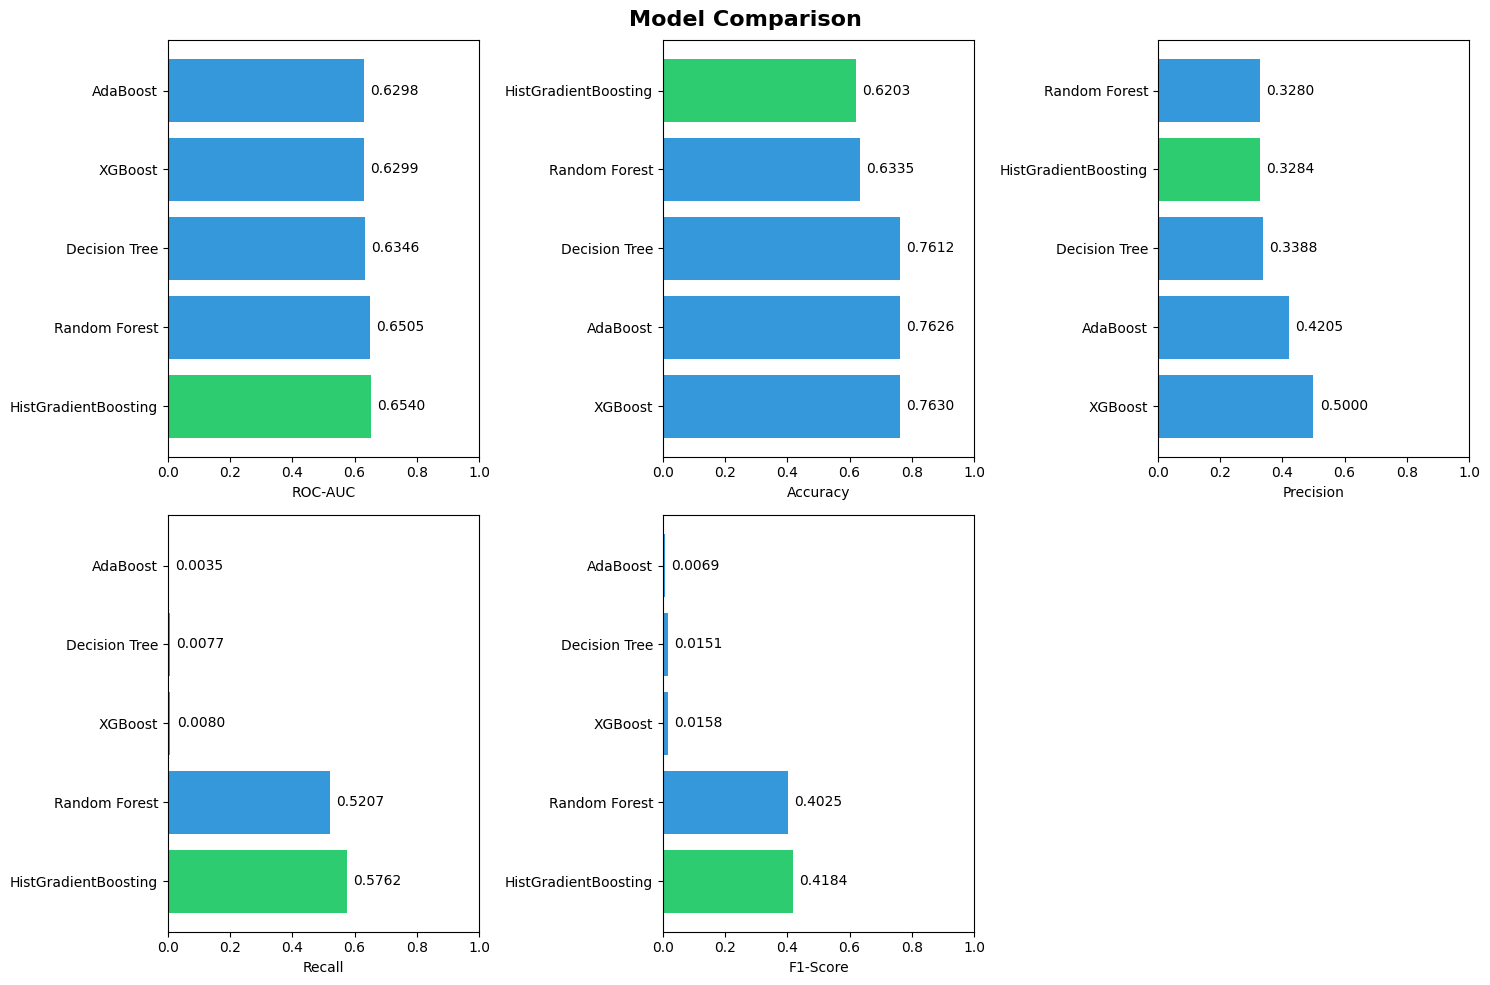

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Model Comparison", fontsize=16, fontweight="bold")

metrics = ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-Score"]
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    comparison_df_sorted = comparison_df.sort(metric, descending=True)
    colors = [
        "#2ecc71" if model == best_model_name else "#3498db"
        for model in comparison_df_sorted["Model"]
    ]
    ax.barh(comparison_df_sorted["Model"], comparison_df_sorted[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
    for i, v in enumerate(comparison_df_sorted[metric]):
        ax.text(v + 0.02, i, f"{v:.4f}", va="center")

# Remove the empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

if EXPORT:
    # Save the plot
    fig.savefig(Path("models/wang/model_comparison.png"), dpi=300, bbox_inches="tight")

# Save the trained models for later use

In [ ]:
import json
from pickle import dump

if EXPORT:
    models_dir = Path("models/wang")
    models_dir.mkdir(parents=True, exist_ok=True)

    with open(f"{models_dir}/model.pkl", "wb") as f:
        dump(calibrated_best_model, f, protocol=5)

    # Save best model metadata with all models' performance
    metadata = {
        "feature_columns": cols,
        "categorical_columns": categorical_cols,
        "categorical_mappings": category_mappings,
        "best_model": best_model_name,
        "best_model_params": search_results[best_model_name],
        "all_models_performance": comparison_df.to_dicts(),  # All model comparisons
        "all_models_best_params": search_results,  # Best params for each model
    }
    with open(models_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, default=str)

    print("Metadata saved to models/metadata.json")
    print(f"Best model for export: {best_model_name}")

[False False False ... False False False]
Metadata saved to models/metadata.json
Best model for export: HistGradientBoosting


/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/Users/ozzysimpson/Git/Flight-Delay/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: